In [1]:
import pandas as pd

data = pd.read_csv("used_cars_UK.csv")

print(data.head(5))

   Unnamed: 0           title  Price  Mileage(miles)  Registration_Year  \
0           0     SKODA Fabia   6900           70189               2016   
1           1  Vauxhall Corsa   1495           88585               2008   
2           2     Hyundai i30    949          137000               2011   
3           3      MINI Hatch   2395           96731               2010   
4           4  Vauxhall Corsa   1000           85000               2013   

   Previous Owners Fuel type  Body type Engine Gearbox  Doors  Seats  \
0              3.0    Diesel  Hatchback   1.4L  Manual    5.0    5.0   
1              4.0    Petrol  Hatchback   1.2L  Manual    3.0    5.0   
2              NaN    Petrol  Hatchback   1.4L  Manual    5.0    5.0   
3              5.0    Petrol  Hatchback   1.4L  Manual    3.0    4.0   
4              NaN    Diesel  Hatchback   1.3L  Manual    5.0    5.0   

  Emission Class Service history  
0         Euro 6             NaN  
1         Euro 4            Full  
2         E

#### A missing service-history value may mean that the seller did not provide service-history information.

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3685 non-null   int64  
 1   title              3685 non-null   str    
 2   Price              3685 non-null   int64  
 3   Mileage(miles)     3685 non-null   int64  
 4   Registration_Year  3685 non-null   int64  
 5   Previous Owners    2276 non-null   float64
 6   Fuel type          3685 non-null   str    
 7   Body type          3685 non-null   str    
 8   Engine             3640 non-null   str    
 9   Gearbox            3685 non-null   str    
 10  Doors              3660 non-null   float64
 11  Seats              3650 non-null   float64
 12  Emission Class     3598 non-null   str    
 13  Service history    540 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 562.1 KB


#### Missing-value report

In [5]:
missing = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Missing Percentage": (data.isnull().sum() / len(data)) * 100
})

missing = missing.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing)

,Missing Values,Missing Percentage
Service history,3145,85.345997
Previous Owners,1409,38.236092
Emission Class,87,2.360923
Engine,45,1.221167
Seats,35,0.949796
Doors,25,0.678426
Registration_Year,0,0.000000
Mileage(miles),0,0.000000
Price,0,0.000000
title,0,0.000000


Service history: 3,145 missing → 85.35%


Previous Owners: 1,409 missing → 38.24%

In [6]:
print("Duplicate rows:", data.duplicated().sum())

print("Unique values:", data["Unnamed: 0"].nunique())
print("Dataset rows:", len(data))

print("\nFirst 10:")
print(data["Unnamed: 0"].head(10).to_list())

print("\nLast 10:")
print(data["Unnamed: 0"].tail(10).to_list())

print("\nPrice Statistics:")
print(data["Price"].describe())

print("Minimum Price:", data["Price"].min())
print("Maximum Price:", data["Price"].max())

Duplicate rows: 0
Unique values: 3685
Dataset rows: 3685

First 10:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Last 10:
[4718, 4719, 4720, 4721, 4722, 4723, 4724, 4725, 4726, 4727]

Price Statistics:
count     3685.000000
mean      5787.145726
std       4480.810572
min        400.000000
25%       2490.000000
50%       4000.000000
75%       7995.000000
max      33900.000000
Name: Price, dtype: float64
Minimum Price: 400
Maximum Price: 33900


#### Investigating the categorical columns

## 4. Categorical Feature Analysis

Categorical features were analyzed to understand their unique values, frequency distribution, and potential data-quality issues.

Key observations:
- `title` contains 469 unique car titles and can be used to derive the car `Brand`.
- `Fuel type` contains 6 categories.
- `Body type` contains 10 categories.
- `Gearbox` contains 2 categories: Manual and Automatic.
- `Engine` contains values such as `1.0L`, `1.2L`, `1.6L`, etc., which can potentially be converted into a numerical engine-size feature.
- `Service history` contains substantial missing values and requires careful treatment rather than simply dropping rows.

These observations will guide the data-cleaning and feature-engineering process.

In [7]:
categorical_columns = [
    "title",
    "Fuel type",
    "Body type",
    "Engine",
    "Gearbox",
    "Emission Class",
    "Service history"
]

for col in categorical_columns:
    print("\n" + "=" * 60)
    print(f"{col}")
    print("=" * 60)
    print("Unique values:", data[col].nunique(dropna=True))
    print(data[col].value_counts(dropna=False).head(20))


title
Unique values: 469
title
Vauxhall Corsa           223
Ford Focus               162
Vauxhall Astra           155
Ford Fiesta              128
BMW 3 Series             109
Renault Clio             105
Volkswagen Polo          101
Toyota Yaris              81
MINI Hatch                78
Mercedes-Benz C Class     58
Volkswagen Golf           56
Peugeot 308               50
Honda Civic               49
Nissan Qashqai            48
Peugeot 207               47
BMW 1 Series              47
Toyota Aygo               47
Vauxhall Insignia         45
SEAT Ibiza                45
Audi A3                   43
Name: count, dtype: int64

Fuel type
Unique values: 6
Fuel type
Petrol                   2361
Diesel                   1218
Petrol Hybrid              47
Electric                   31
Petrol Plug-in Hybrid      27
Diesel Hybrid               1
Name: count, dtype: int64

Body type
Unique values: 10
Body type
Hatchback      2279
SUV             460
Saloon          368
Estate          171

In [8]:
print("REGISTRATION YEAR")
print(data["Registration_Year"].value_counts().sort_index())

print("\nPREVIOUS OWNERS")
print(data["Previous Owners"].value_counts(dropna=False).sort_index())

print("\nEMISSION CLASS")
print(data["Emission Class"].value_counts(dropna=False))

print("\nDOORS")
print(data["Doors"].value_counts(dropna=False).sort_index())

print("\nSEATS")
print(data["Seats"].value_counts(dropna=False).sort_index())

print("\nTITLE SAMPLE")
print(data["title"].sample(30, random_state=42).to_list())

REGISTRATION YEAR
Registration_Year
1953      1
1972      1
1981      1
1985      1
1987      2
1988      2
1989      1
1990      3
1991      2
1992      1
1993      1
1995      3
1996      1
1997      3
1998      3
1999      5
2000      4
2001     25
2002     30
2003     53
2004     72
2005    104
2006    149
2007    246
2008    226
2009    251
2010    271
2011    289
2012    275
2013    242
2014    287
2015    210
2016    245
2017    164
2018     95
2019    211
2020    106
2021     85
2022      8
2023      6
Name: count, dtype: int64

PREVIOUS OWNERS
Previous Owners
1.0     523
2.0     594
3.0     475
4.0     360
5.0     208
6.0      60
7.0      39
8.0      12
9.0       5
NaN    1409
Name: count, dtype: int64

EMISSION CLASS
Emission Class
Euro 5    1256
Euro 6    1108
Euro 4    1068
Euro 3     137
NaN         87
Euro 2      25
Euro 1       4
Name: count, dtype: int64

DOORS
Doors
2.0     216
3.0     735
4.0     367
5.0    2342
NaN      25
Name: count, dtype: int64

SEATS
Seats
2.0  

## Data Understanding Summary

The dataset contains 3,685 used-car records with no duplicate rows.

Key observations:
- `Unnamed: 0` behaves as a row identifier and will not be used as a predictive feature.
- `Price` ranges from £400 to £33,900 and is right-skewed.
- `Registration_Year` ranges from 1953 to 2023, with most vehicles concentrated in recent years.
- `Previous Owners` contains substantial missing values.
- `Emission Class`, `Doors`, and `Seats` contain relatively few missing values.
- `title` contains detailed car names and can be used to derive the `Brand` feature.
- `Engine` can potentially be converted from text such as `1.6L` into a numerical engine-size feature.
- `Service history` has a high proportion of missing values and requires careful treatment.

These observations will guide the data-cleaning and feature-engineering stages.

We have years from 1953 to 2023.

Most vehicles are concentrated between roughly 2005–2021, but there are a few very old vehicles such as 1953, 1972, 1981, etc.

We should not automatically delete them. A 1953 vehicle could be a legitimate classic car.

We'll inspect their prices later during EDA/error analysis.

### Creating a working copy and remove the identifier

In [9]:
# Create a working copy
df = data.copy()

# Remove the dataset index column
df.drop(columns=["Unnamed: 0"], inplace=True)

print("Shape after removing identifier:", df.shape)
print(df.head())

Shape after removing identifier: (3685, 13)
            title  Price  Mileage(miles)  Registration_Year  Previous Owners  \
0     SKODA Fabia   6900           70189               2016              3.0   
1  Vauxhall Corsa   1495           88585               2008              4.0   
2     Hyundai i30    949          137000               2011              NaN   
3      MINI Hatch   2395           96731               2010              5.0   
4  Vauxhall Corsa   1000           85000               2013              NaN   

  Fuel type  Body type Engine Gearbox  Doors  Seats Emission Class  \
0    Diesel  Hatchback   1.4L  Manual    5.0    5.0         Euro 6   
1    Petrol  Hatchback   1.2L  Manual    3.0    5.0         Euro 4   
2    Petrol  Hatchback   1.4L  Manual    5.0    5.0         Euro 5   
3    Petrol  Hatchback   1.4L  Manual    3.0    4.0         Euro 4   
4    Diesel  Hatchback   1.3L  Manual    5.0    5.0         Euro 5   

  Service history  
0             NaN  
1            F

## Creating Brand

## Feature Engineering: Brand

The `title` column contains the manufacturer and model name. 
The first token is used to derive a new `Brand` feature, allowing the model to learn differences in vehicle prices across manufacturers.

In [11]:
# Extract brand from the car title
df["Brand"] = df["title"].str.split().str[0]

# Check the result
print(df[["title", "Brand"]].head(10))

print("\nNumber of unique brands:", df["Brand"].nunique())

print("\nTop 20 brands:")
print(df["Brand"].value_counts().head(20))

            title     Brand
0     SKODA Fabia     SKODA
1  Vauxhall Corsa  Vauxhall
2     Hyundai i30   Hyundai
3      MINI Hatch      MINI
4  Vauxhall Corsa  Vauxhall
5   Hyundai Coupe   Hyundai
6      Ford Focus      Ford
7  Vauxhall Corsa  Vauxhall
8       Volvo 740     Volvo
9     Peugeot 207   Peugeot

Number of unique brands: 48

Top 20 brands:
Brand
Vauxhall         550
Ford             410
Volkswagen       272
BMW              269
Peugeot          245
Toyota           195
Nissan           180
Renault          175
Mercedes-Benz    168
Audi             147
Honda            108
Fiat             104
MINI              97
Citroen           95
Hyundai           93
KIA               81
SKODA             63
SEAT              60
Mazda             54
Suzuki            41
Name: count, dtype: int64


### Creating Car_Age

## Feature Engineering: Car Age

Vehicle age is expected to have a strong relationship with used-car prices. 
A `Car_Age` feature is created from `Registration_Year` using 2023 as the reference year, matching the latest registration year present in the dataset.

In [12]:
REFERENCE_YEAR = 2023

df["Car_Age"] = REFERENCE_YEAR - df["Registration_Year"]

print(df[["Registration_Year", "Car_Age"]].head(10))

print("\nCar Age statistics:")
print(df["Car_Age"].describe())

   Registration_Year  Car_Age
0               2016        7
1               2008       15
2               2011       12
3               2010       13
4               2013       10
5               2007       16
6               2008       15
7               2009       14
8               1989       34
9               2008       15

Car Age statistics:
count    3685.000000
mean       11.164993
std         5.092566
min         0.000000
25%         8.000000
50%        11.000000
75%        15.000000
max        70.000000
Name: Car_Age, dtype: float64


## Feature Engineering: Engine Size

The `Engine` column is stored as text values such as `1.4L` and `2.0L`. 
The numeric engine displacement is extracted into a new `Engine_Litres` feature so that the model can use engine size as a numerical variable.

In [13]:
df["Engine_Litres"] = (
    df["Engine"]
    .str.replace("L", "", regex=False)
    .astype(float)
)

print(df[["Engine", "Engine_Litres"]].head(10))

print("\nEngine_Litres statistics:")
print(df["Engine_Litres"].describe())

  Engine  Engine_Litres
0   1.4L            1.4
1   1.2L            1.2
2   1.4L            1.4
3   1.4L            1.4
4   1.3L            1.3
5   2.0L            2.0
6   1.6L            1.6
7   1.2L            1.2
8   2.3L            2.3
9   1.6L            1.6

Engine_Litres statistics:
count    3640.000000
mean        1.606264
std         0.486718
min         0.800000
25%         1.300000
50%         1.600000
75%         1.900000
max         6.300000
Name: Engine_Litres, dtype: float64


### Feature Engineering Summary

Three new features were created:

- `Brand`: extracted from the first token of the vehicle title.
- `Car_Age`: calculated as 2023 minus `Registration_Year`.
- `Engine_Litres`: extracted from the numeric portion of the `Engine` column.

These features provide more meaningful representations of manufacturer, vehicle age, and engine size for the machine learning models.

# EDA

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of the target variable and relationships between vehicle characteristics and price.

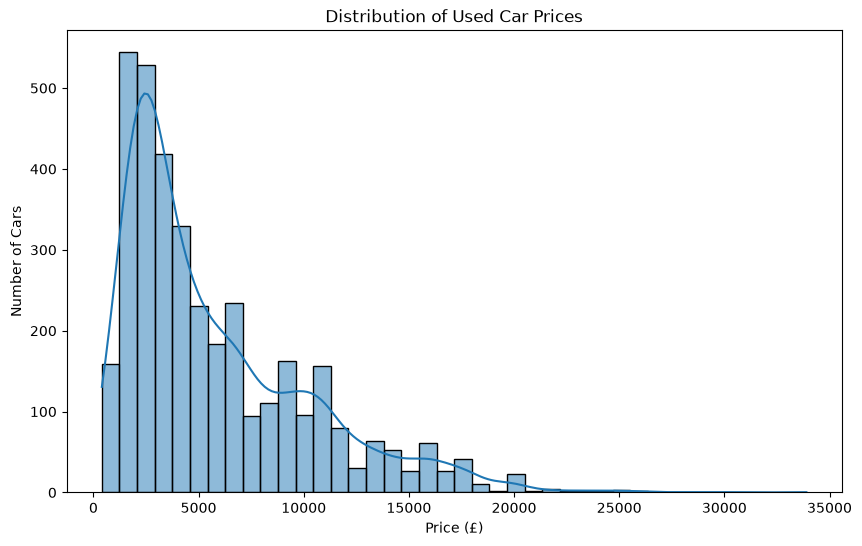

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Cars")
plt.show()

### Observation

The price distribution is right-skewed, with most vehicles concentrated in the lower price range and fewer vehicles at higher prices. The median price (£4,000) is lower than the mean price (£5,787), which supports the presence of right skewness.

## Price vs Fuel Type

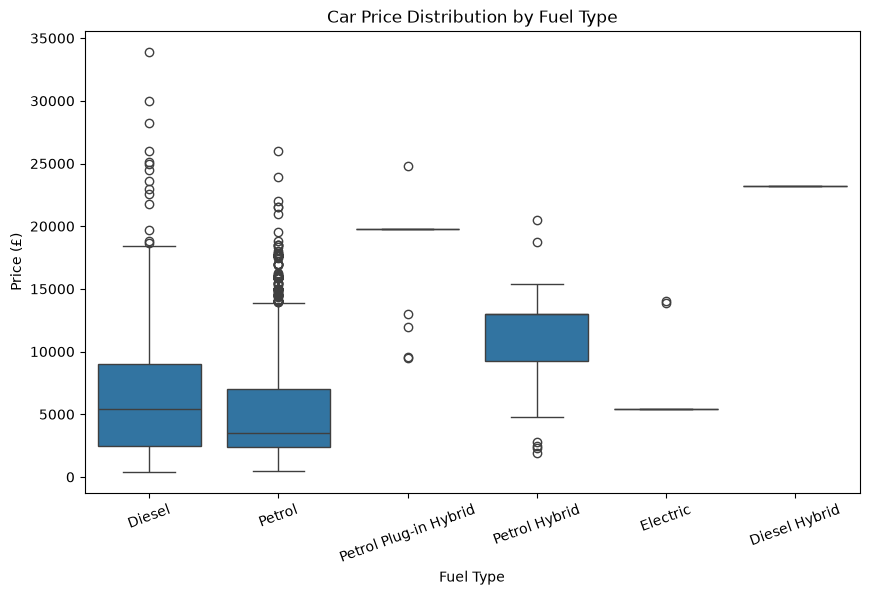

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Fuel type",
    y="Price"
)

plt.title("Car Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (£)")
plt.xticks(rotation=20)
plt.show()

### Observation

The boxplot shows how used-car prices vary across different fuel types. The distributions and spread differ between fuel categories, indicating that fuel type may provide useful information for predicting vehicle price4
.

#
# Price vs Car Age

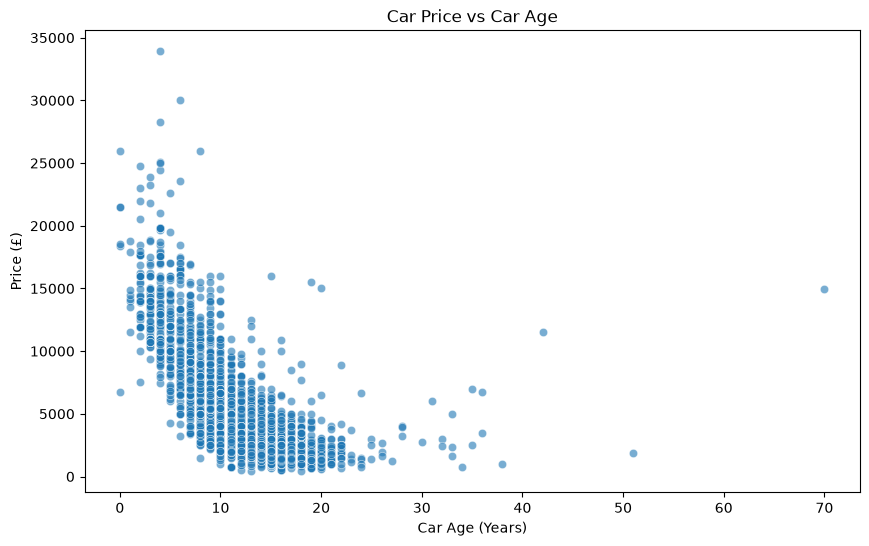

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Price",
    alpha=0.6
)

plt.title("Car Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Price (£)")
plt.show()

## Correlation Heatmap

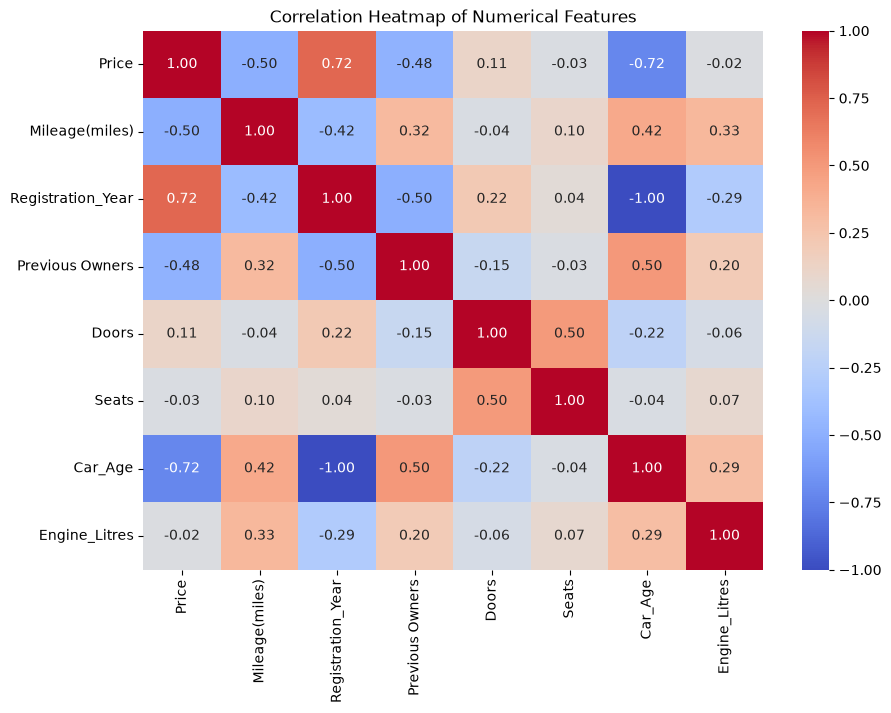

In [17]:
numeric_columns = [
    "Price",
    "Mileage(miles)",
    "Registration_Year",
    "Previous Owners",
    "Doors",
    "Seats",
    "Car_Age",
    "Engine_Litres"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Observation

The correlation heatmap shows the linear relationships between numerical variables. `Car_Age`, `Registration_Year`, `Mileage(miles)`, and `Engine_Litres` are particularly relevant numerical features for understanding variations in used-car prices.

Correlation measures linear association and does not necessarily imply causation.